# 04 · Cohort Retention

This notebook is about "where are we losing customers?". I group customers by the month of their
first order (their *cohort*), then track what share of each cohort comes back to order in each
later month.

Two things to keep in mind:

- **December 2011 is dropped.** The data stops on 9 December, so that month would make every
  cohort look like it fell off a cliff at the end.
- **The December 2009 cohort isn't really new customers.** The data starts on 1 December 2009,
  so anyone who ordered that month is counted as "new" even if they'd been buying for years. I
  keep it in the heatmap but leave it out of the average retention curve and show it separately.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from style import BLUE, ORANGE, GREY, DARK_BLUE, TEXT_MUTED, BLUE_RAMP, set_style, save_fig, titles

set_style()
pd.set_option("display.float_format", "{:,.3f}".format)

df = pd.read_csv("../data/processed/clean.csv", parse_dates=["InvoiceDate"], dtype={"Invoice": str, "StockCode": str})
df["CustomerID"] = df["CustomerID"].astype(int)

df = df[df["InvoiceDate"] < "2011-12-01"]      # full months only
print(f"{len(df):,} rows, {df.CustomerID.nunique():,} customers, "
      f"{df.InvoiceDate.min():%b %Y} to {df.InvoiceDate.max():%b %Y}")

753,463 rows, 5,812 customers, Dec 2009 to Nov 2011


## 1. Build the cohort table

In [2]:
def build_retention(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Return (retention matrix, cohort sizes).

    Rows are cohorts (month of first order), columns are months since the first order,
    and each cell is the share of the cohort that placed at least one order that month.
    """
    orders = frame[["CustomerID", "InvoiceDate"]].copy()
    orders["OrderMonth"] = orders["InvoiceDate"].dt.to_period("M")
    orders["Cohort"] = orders.groupby("CustomerID")["OrderMonth"].transform("min")
    orders["MonthsSince"] = (orders["OrderMonth"] - orders["Cohort"]).apply(lambda d: d.n)

    active = (orders.groupby(["Cohort", "MonthsSince"])["CustomerID"].nunique()
                    .unstack("MonthsSince"))
    sizes = active[0].astype(int)
    return active.div(sizes, axis=0), sizes


retention, cohort_sizes = build_retention(df)
print(f"{len(retention)} cohorts x {retention.shape[1]} months")
cohort_sizes.to_frame("New customers").T

24 cohorts x 24 months


Cohort,2009-12,2010-01,2010-02,2010-03,2010-04,2010-05,2010-06,2010-07,2010-08,2010-09,...,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11
New customers,951,366,374,441,294,253,267,187,162,236,...,126,178,106,113,108,101,107,185,221,190


In [3]:
first_cohort = retention.index[0]
newer = retention.drop(index=first_cohort)
print(f"{first_cohort} cohort: {cohort_sizes.iloc[0]:,} customers vs median of {cohort_sizes.iloc[1:].median():,.0f} for later cohorts")
# Early-2010 cohorts still contain some older customers who just didn't order in Dec 2009, so the
# fairer comparison of acquisition is the second half of each year.
h2_2010 = cohort_sizes["2010-06":"2010-11"].sum()
h2_2011 = cohort_sizes["2011-06":"2011-11"].sum()
print(f"New customers Jun-Nov 2010: {h2_2010:,}   Jun-Nov 2011: {h2_2011:,}   ({h2_2011 / h2_2010 - 1:+.1%})")
retention.round(3).iloc[:6, :13]

2009-12 cohort: 951 customers vs median of 187 for later cohorts
New customers Jun-Nov 2010: 1,548   Jun-Nov 2011: 912   (-41.1%)


MonthsSince,0,1,2,3,4,5,6,7,8,9,10,11,12
Cohort,,,,,,,,,,,,,
2009-12,1.000,0.348,0.333,0.423,0.377,0.360,0.376,0.344,0.336,0.361,0.422,0.495,0.376
2010-01,1.000,0.210,0.317,0.317,0.270,0.311,0.268,0.235,0.287,0.325,0.306,0.172,0.230
2010-02,1.000,0.235,0.227,0.294,0.246,0.195,0.193,0.289,0.257,0.275,0.115,0.126,0.150
2010-03,1.000,0.188,0.231,0.243,0.229,0.202,0.243,0.308,0.277,0.109,0.113,0.145,0.200
2010-04,1.000,0.190,0.190,0.160,0.184,0.221,0.276,0.265,0.109,0.109,0.075,0.139,0.143
2010-05,1.000,0.154,0.170,0.178,0.178,0.257,0.213,0.126,0.059,0.083,0.115,0.134,0.154


## 2. Retention heatmap

Month 0 is always 100% (that's the month they joined), so I leave it out of the colour scale. If I
didn't, every other cell would be pale.

saved 10_cohort_retention_heatmap.png


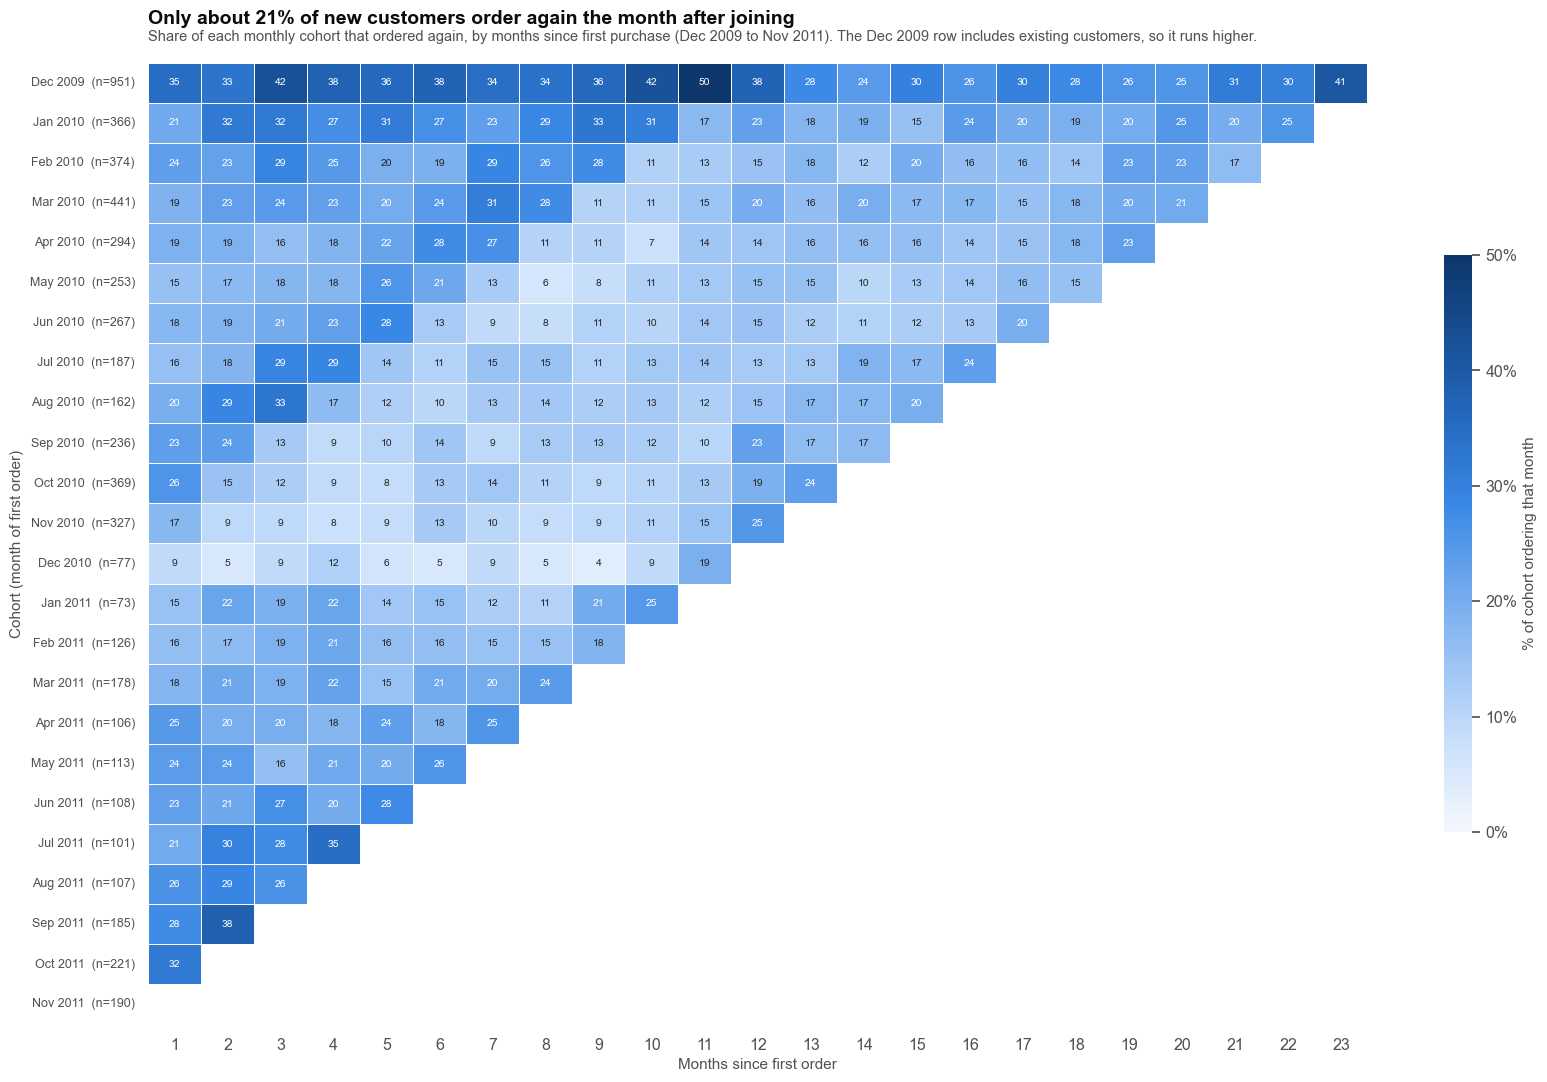

In [4]:
heat = retention.drop(columns=0) * 100
labels = [f"{p.strftime('%b %Y')}  (n={n:,})" for p, n in zip(retention.index, cohort_sizes)]

fig, ax = plt.subplots(figsize=(17, 11))
sns.heatmap(heat, cmap=BLUE_RAMP, vmin=0, vmax=50, annot=True, fmt=".0f", annot_kws={"fontsize": 7.5},
            linewidths=0.6, linecolor="white", mask=heat.isna(),
            cbar_kws={"label": "% of cohort ordering that month", "shrink": 0.6, "format": "%.0f%%"}, ax=ax)
ax.set_yticklabels(labels, rotation=0, fontsize=9)
ax.grid(False)
ax.set_xlabel("Months since first order")
ax.set_ylabel("Cohort (month of first order)")

m1_avg = newer[1].mean() * 100
titles(ax, f"Only about {m1_avg:.0f}% of new customers order again the month after joining",
       "Share of each monthly cohort that ordered again, by months since first purchase (Dec 2009 to Nov 2011). "
       "The Dec 2009 row includes existing customers, so it runs higher.")
fig.tight_layout()
save_fig(fig, "10_cohort_retention_heatmap")
plt.show()

## 3. Average retention curve

I average across cohorts (each cohort counts equally) and only plot a month if at least six cohorts
have reached it, so the tail isn't driven by one or two groups.

In [5]:
MIN_COHORTS = 6
counts = newer.notna().sum()
curve = newer.mean()[counts >= MIN_COHORTS] * 100
curve_dec09 = retention.loc[first_cohort] * 100

for m in [1, 2, 3, 6, 12]:
    print(f"Month {m:>2}: new cohorts avg {curve[m]:5.1f}%   |   Dec 2009 cohort {curve_dec09[m]:5.1f}%")
print(f"\nCohorts counted per month (first/last plotted): {counts[1]} / {counts[curve.index.max()]}")

Month  1: new cohorts avg  20.6%   |   Dec 2009 cohort  34.8%
Month  2: new cohorts avg  21.7%   |   Dec 2009 cohort  33.3%
Month  3: new cohorts avg  21.0%   |   Dec 2009 cohort  42.3%
Month  6: new cohorts avg  17.3%   |   Dec 2009 cohort  37.6%
Month 12: new cohorts avg  17.9%   |   Dec 2009 cohort  37.6%

Cohorts counted per month (first/last plotted): 22 / 6


saved 11_average_retention_curve.png


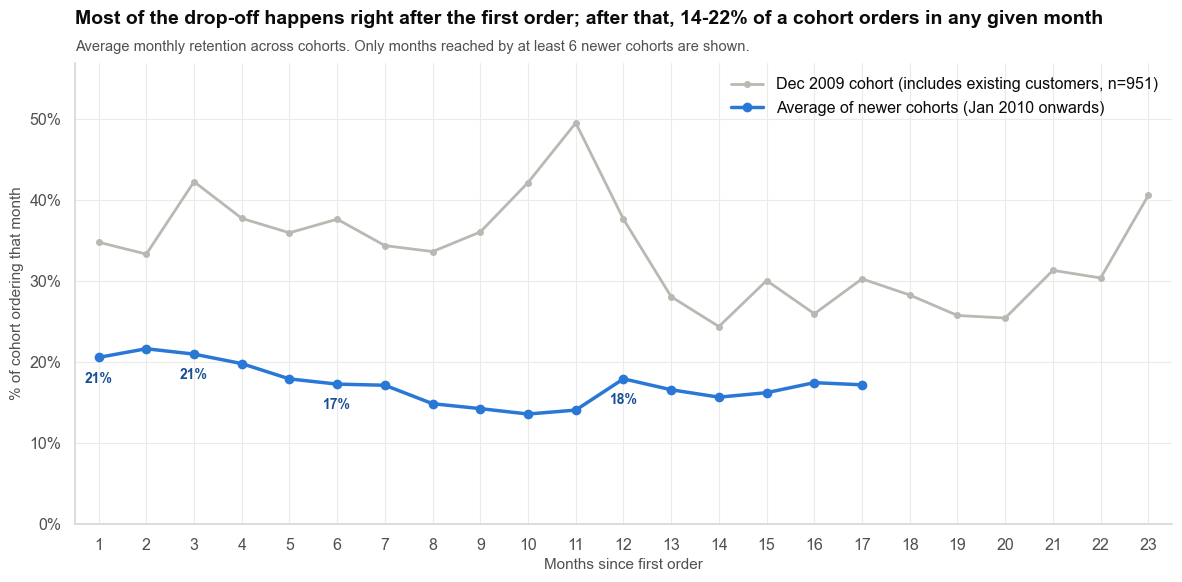

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(curve_dec09.index[1:], curve_dec09.values[1:], color=GREY, lw=2, marker="o", ms=4,
        label=f"Dec 2009 cohort (includes existing customers, n={cohort_sizes.iloc[0]:,})")
ax.plot(curve.index[1:], curve.values[1:], color=BLUE, lw=2.5, marker="o", ms=6,
        label="Average of newer cohorts (Jan 2010 onwards)")

for m in [1, 3, 6, 12]:
    ax.annotate(f"{curve[m]:.0f}%", (m, curve[m]), xytext=(0, -18), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold", color=DARK_BLUE)

ax.set_xlim(0.5, max(curve.index.max(), curve_dec09.index.max()) + 0.5)
ax.set_ylim(0, max(curve_dec09.values[1:].max(), curve.values[1:].max()) * 1.15)
ax.set_xticks(range(1, int(curve_dec09.index.max()) + 1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Months since first order")
ax.set_ylabel("% of cohort ordering that month")
ax.legend(loc="upper right")
titles(ax, f"Most of the drop-off happens right after the first order; after that, {curve[1:].min():.0f}-{curve[1:].max():.0f}% "
           "of a cohort orders in any given month",
       f"Average monthly retention across cohorts. Only months reached by at least {MIN_COHORTS} newer cohorts are shown.")
fig.tight_layout()
save_fig(fig, "11_average_retention_curve")
plt.show()

## 4. Do new customers ever come back?

In [7]:
# Share of each cohort that placed a second order at any point (not just the next month)
orders = df.groupby("CustomerID").agg(First=("InvoiceDate", "min"), Orders=("Invoice", "nunique"))
orders["Cohort"] = orders["First"].dt.to_period("M")
repeat = orders.groupby("Cohort")["Orders"].apply(lambda o: (o > 1).mean())

new_only = orders[orders.Cohort > first_cohort]
print(f"Customers acquired Jan 2010 onwards who ever placed a second order: {(new_only.Orders > 1).mean():.1%}")
print(f"Customers in the Dec 2009 cohort who placed a second order: {repeat.iloc[0]:.1%}")

# Compare cohorts that have had a full 12 months to come back
mature = repeat["2010-01":"2010-11"]
print(f"2010 cohorts (Jan-Nov) with 12+ months of history: {mature.mean():.1%} came back at least once")

Customers acquired Jan 2010 onwards who ever placed a second order: 67.9%
Customers in the Dec 2009 cohort who placed a second order: 91.3%
2010 cohorts (Jan-Nov) with 12+ months of history: 75.5% came back at least once


In [8]:
# The seasonal pattern shows up in retention too: a cohort's return rate jumps in November
by_calendar = newer.stack().rename("Retention").reset_index()
by_calendar["CalendarMonth"] = (by_calendar["Cohort"] + by_calendar["MonthsSince"]).dt.month
by_calendar = by_calendar[by_calendar.MonthsSince > 0]
cal = by_calendar.groupby("CalendarMonth")["Retention"].mean() * 100
print("Average return rate by calendar month (newer cohorts, months 1+):")
print(cal.round(1).to_string())

Average return rate by calendar month (newer cohorts, months 1+):
CalendarMonth
1    11.300
2    11.900
3    15.900
4    15.400
5    18.300
6    17.200
7    16.500
8    15.600
9    19.600
10   21.700
11   25.000
12   13.800


## What the data shows

The heatmap and the curve tell the same story. The biggest loss happens straight after the first
order: on average only **20.6%** of a new cohort orders again the following month. After that,
retention barely moves. It stays somewhere between 14% and 22% a month for as long as we can
track it (17.3% at month 6, 17.9% at month 12). That doesn't mean four out of five customers are
gone for good. Of the customers who joined between Jan and Nov 2010, **75.5% placed a second order
at some point**. They just don't buy every month, which fits a wholesale customer who restocks
every few months.

Seasonality shows up in the heatmap as diagonal stripes. Every cohort gets more active in the
autumn: across the newer cohorts the average return rate is **25.0% in November** compared with
**11.3% in January**.

The more worrying signal is acquisition. **912 new customers joined in Jun-Nov 2011 compared with
1,548 in the same months of 2010, a 41% drop.** With revenue flat year on year, the business is
leaning harder on existing customers each year.

## Key Takeaways

- **Month-1 retention averages 20.6%** for cohorts from Jan 2010 onwards, and it stays between 14% and 22% a month after that (17.9% at month 12).
- **Most customers do come back eventually.** 75.5% of the 2010 cohorts placed a second order within the data window, just not on a monthly rhythm.
- **The Dec 2009 cohort retains about twice as well** (34.8% at month 1, 37.6% at month 12) because it's mostly established customers, not new ones. Mixing it into the average would make retention look much better than it is.
- **November is when lapsed customers come back:** a 25.0% average return rate vs 11.3% in January. That makes Sep-Oct the natural window for win-back campaigns.
- **New-customer acquisition fell 41%** (1,548 in Jun-Nov 2010 to 912 in Jun-Nov 2011). Flat revenue (+1.7%) despite fewer new customers means growth now depends on existing accounts.